**모델훈련 단계**
1. 라이브러리 불러오기 (머신러닝(sklearn, 딥러닝(tensorflow, toach))
2. 데이터 불러오기
3. 데이터 탐색 및 전처리 (데이터 분할, 스케일링, 원핫인코딩, 레이블인코딩)
4. 모델 구축
5. 모델 훈련
6. 결과 확인(수치적 확인, 시각적 확인)

In [1]:
# 라이브러리 불러오기
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split              # 데이터 분할
from sklearn.preprocessing import StandardScaler, OneHotEncoder   # 데이터 전처리(문자형 데이터 : 원핫인코딩(수치형으로 변형) , StandardScaler : 정규화)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from tensorflow.keras.models import Sequential                    # 인공지능 라이브러리 (Sequential )
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# 1. 데이터 로드
# 타이타닉 데이터셋 불러오기 (예: Kaggle에서 다운로드한 파일)
train_data = pd.read_csv('/content/train.csv')

# 2. 데이터 탐색
print("데이터 형태:", train_data.shape)
print("\n데이터 미리보기:")
print(train_data.head())
print("\n데이터 정보:")
print(train_data.info())
print("\n기본 통계:")
print(train_data.describe())

데이터 형태: (891, 12)

데이터 미리보기:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450

In [4]:
# 3. 데이터 전처리
# 사용할 특성 선택
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
X = train_data[features]
y = train_data['Survived']

# 숫자형과 범주형 특성 구분
numeric_features = ['Age', 'SibSp', 'Parch', 'Fare']
categorical_features = ['Pclass', 'Sex', 'Embarked']

# 전처리 파이프라인 정의
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [5]:
# 데이터 분할 (학습/테스트)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 전처리 적용
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

# 전처리된 데이터의 차원 확인
print(f"전처리된 특성 데이터 형태: {X_train_preprocessed.shape}")

전처리된 특성 데이터 형태: (712, 12)


In [15]:
# 4. 인공신경망 모델 구축
model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_preprocessed.shape[1],)),
    Dropout(0.2),  # 과적합 방지
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

In [16]:
# 모델 컴파일
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# 모델 요약
model.summary()
#  Param #  은 weight값으로 보면 됨
#  마지막에 왜 17이냐면 bias 값이 하나 추가 됨

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                      │ (None, 32)                  │             416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 961 (3.75 KB)

 Trainable params: 961 (3.75 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# 5. 모델 학습
history = model.fit(
    X_train_preprocessed, y_train,
    epochs=100,
    batch_size=32, # ram 에 데이터 쪼개넣기
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.4984 - loss: 0.7143 - val_accuracy: 0.6853 - val_loss: 0.5980
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6777 - loss: 0.6080 - val_accuracy: 0.7343 - val_loss: 0.5415
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7131 - loss: 0.5794 - val_accuracy: 0.7483 - val_loss: 0.5106
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7448 - loss: 0.5470 - val_accuracy: 0.7622 - val_loss: 0.4824
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7695 - loss: 0.5175 - val_accuracy: 0.7902 - val_loss: 0.4586
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7808 - loss: 0.4937 - val_accuracy: 0.8252 - val_loss: 0.4417
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8244 - loss: 0.4801 - val_accuracy: 0.8252 - val_loss: 0.4284
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8083 - loss: 0.4840 - val_accuracy: 0.8252 - 

In [17]:
# 6. 모델 평가
# 테스트 세트에 대한 예측
y_pred_prob = model.predict(X_test_preprocessed)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [18]:
# 정확도 계산
accuracy = accuracy_score(y_test, y_pred)
print(f"테스트 세트 정확도: {accuracy:.4f}")

테스트 세트 정확도: 0.3464



분류 보고서:
              precision    recall  f1-score   support

           0       0.31      0.10      0.15       105
           1       0.35      0.70      0.47        74

    accuracy                           0.35       179
   macro avg       0.33      0.40      0.31       179
weighted avg       0.33      0.35      0.28       179



/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 47581 (\N{HANGUL SYLLABLE MANG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 49373 (\N{HANGUL SYLLABLE SAENG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51316 (\N{HANGUL SYLLABLE JON}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from 

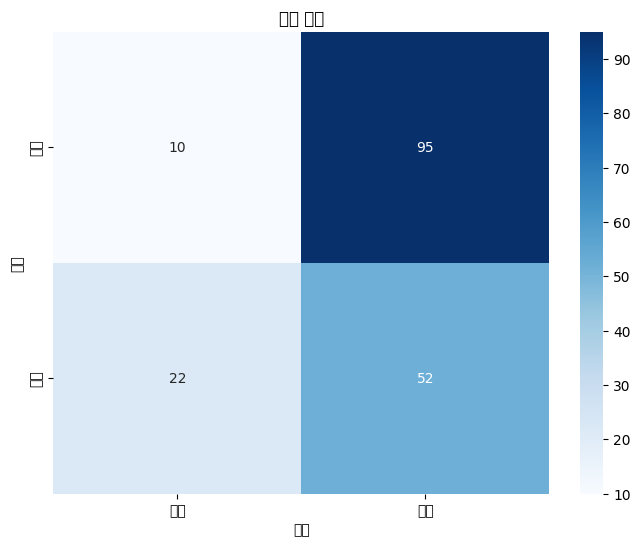

In [19]:
# 분류 보고서
print("\n분류 보고서:")
print(classification_report(y_test, y_pred))

# 혼동 행렬
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['사망', '생존'],
            yticklabels=['사망', '생존'])
plt.xlabel('예측')
plt.ylabel('실제')
plt.title('혼동 행렬')
plt.show()

<ipython-input-20-24831a97d7c1>:20: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-20-24831a97d7c1>:20: UserWarning: Glyph 54253 (\N{HANGUL SYLLABLE POG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-20-24831a97d7c1>:20: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-20-24831a97d7c1>:20: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-20-24831a97d7c1>:20: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-20-24831a97d7c1>:20: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-20-24831a97d7c1>:20: UserWarning: Glyph 45944 (\N{HANGUL SYLLABLE DEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipytho

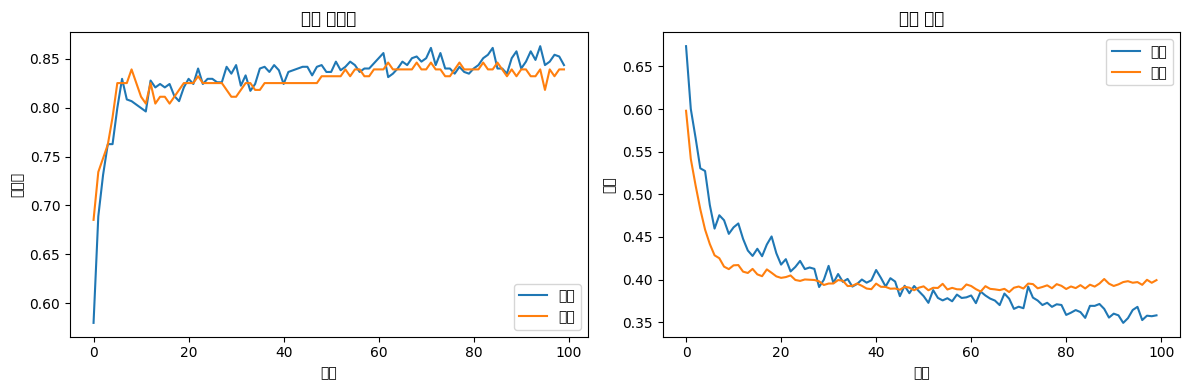

In [20]:
# 7. 학습 과정 시각화
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('모델 정확도')
plt.ylabel('정확도')
plt.xlabel('에폭')
plt.legend(['학습', '검증'], loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('모델 손실')
plt.ylabel('손실')
plt.xlabel('에폭')
plt.legend(['학습', '검증'], loc='upper right')

plt.tight_layout()
plt.show()

In [21]:
# 8. 중요 특성 시각화 (예시: 간접적인 방법)
# 전처리된 특성의 이름 가져오기
# (OneHotEncoder로 변환된 범주형 특성 이름 포함)
transformed_features = []
for name, transformer, features in preprocessor.transformers_:
    if name == 'cat':
        for i, feature in enumerate(features):
            categories = transformer.named_steps['onehot'].categories_[i]
            for category in categories:
                transformed_features.append(f"{feature}_{category}")
    else:
        transformed_features.extend(features)

In [22]:
# 첫 번째 레이어의 가중치 가져오기
weights = model.layers[0].get_weights()[0]

# 특성별 가중치 크기 계산
feature_importance = np.sum(np.abs(weights), axis=1)

# 특성 중요도 정렬 및 상위 10개 선택
indices = np.argsort(feature_importance)[::-1][:10]
top_features = [transformed_features[i] if i < len(transformed_features) else f"feature_{i}" for i in indices]
top_importance = feature_importance[indices]

<ipython-input-23-c1a7b298fa94>:7: UserWarning: Glyph 53945 (\N{HANGUL SYLLABLE TEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-23-c1a7b298fa94>:7: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-23-c1a7b298fa94>:7: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-23-c1a7b298fa94>:7: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-23-c1a7b298fa94>:7: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-23-c1a7b298fa94>:7: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-23-c1a7b298fa94>:7: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-in

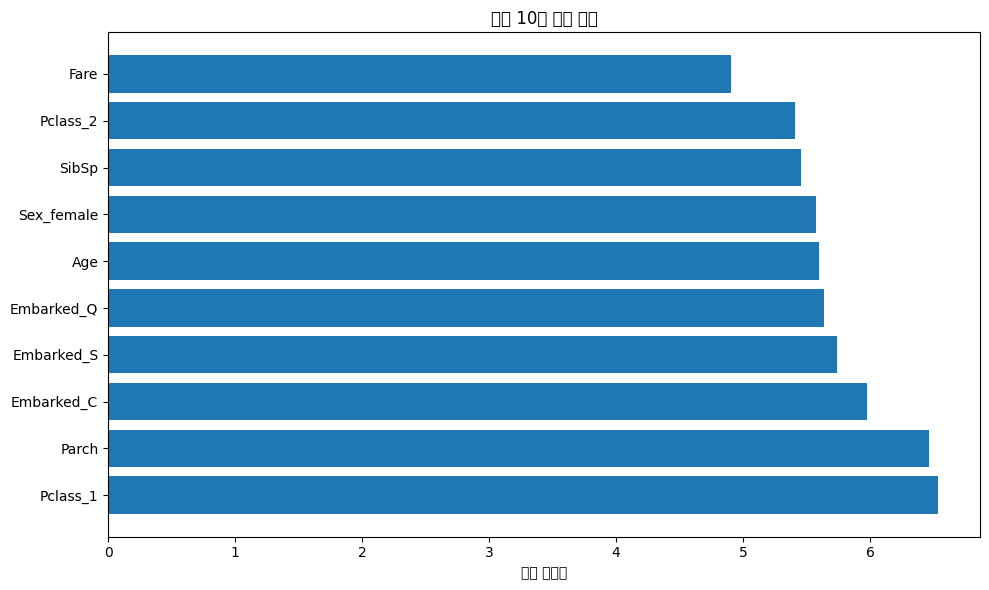

In [23]:
# 시각화
plt.figure(figsize=(10, 6))
plt.barh(range(len(top_features)), top_importance, align='center')
plt.yticks(range(len(top_features)), top_features)
plt.xlabel('특성 중요도')
plt.title('상위 10개 중요 특성')
plt.tight_layout()
plt.show()

In [24]:
# 9. 테스트 데이터 예측 결과 상세 분석
test_results = pd.DataFrame({
    'PassengerId': train_data.iloc[X_test.index]['PassengerId'],
    'Actual': y_test,
    'Predicted': y_pred,
    'Probability': y_pred_prob.flatten()
})

# 예측 결과 정렬 (확률 기준)
test_results = test_results.sort_values('Probability', ascending=False)

print("\n테스트 데이터 예측 결과 (상위 10개):")
print(test_results.head(10))

# 틀린 예측 분석
wrong_predictions = test_results[test_results['Actual'] != test_results['Predicted']]
print("\n틀린 예측 개수:", len(wrong_predictions))
print("\n틀린 예측 샘플 (상위 5개):")
print(wrong_predictions.head(5))


테스트 데이터 예측 결과 (상위 10개):
     PassengerId  Actual  Predicted  Probability
25            26       1          1     0.756588
86            87       0          1     0.734914
360          361       0          1     0.699830
63            64       0          1     0.658454
885          886       0          1     0.651708
819          820       0          1     0.648940
362          363       0          1     0.629717
333          334       0          1     0.621976
417          418       1          1     0.621717
165          166       1          1     0.619263

틀린 예측 개수: 117

틀린 예측 샘플 (상위 5개):
     PassengerId  Actual  Predicted  Probability
86            87       0          1     0.734914
360          361       0          1     0.699830
63            64       0          1     0.658454
885          886       0          1     0.651708
819          820       0          1     0.648940
